# 🧠 **BUSINESS CONTEXT**

Mayoritas penjual di marketplace merupakan seller skala kecil (SMB/UMKM) yang berkontribusi besar terhadap total transaksi secara agregat, namun banyak di antaranya belum berkembang secara optimal.
Tantangan utama bisnis bukan sekadar menarik seller baru, tetapi membantu seller eksisting untuk meningkatkan performa secara berkelanjutan.

# **🎯 TUJUAN BISNIS ANALISIS**

1. Mengidentifikasi seller dengan performa tinggi dan rendah
2. Menemukan faktor kunci yang memengaruhi GMV dan pertumbuhan seller
3. Menentukan area perbaikan operasional yang paling berdampak
4. Mendukung pengambilan keputusan berbasis data untuk pengembangan seller UMKM

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
seller_level = pd.read_csv("/content/drive/MyDrive/Data Analyst/Project/Analysis E-Commerce/seller_level.csv")

In [ ]:
seller_level.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2959 entries, 0 to 2958
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   seller_id                      2959 non-null   object 
 1   total_gmv                      2959 non-null   float64
 2   total_items_sold               2959 non-null   int64  
 3   total_orders                   2959 non-null   int64  
 4   avg_item_price                 2959 non-null   float64
 5   median_seller_processing_days  2959 non-null   float64
 6   median_delivery_time_days      2959 non-null   float64
 7   late_delivery_rate             2959 non-null   float64
 8   avg_review_score               2954 non-null   float64
 9   review_coverage                2959 non-null   float64
 10  product_category               2959 non-null   object 
dtypes: float64(7), int64(2), object(2)
memory usage: 254.4+ KB


In [ ]:
seller_level.describe()

,total_gmv,total_items_sold,total_orders,avg_item_price,median_seller_processing_days,median_delivery_time_days,late_delivery_rate,avg_review_score,review_coverage
count,2959.000000,2959.000000,2959.000000,2959.000000,2959.000000,2959.000000,2959.000000,2954.000000,2959.000000
mean,4407.930872,36.694153,36.694153,177.757246,2.361947,6.904022,0.069310,4.152059,0.992798
std,13813.893656,118.352664,118.352664,345.682115,3.751937,5.443661,0.158527,0.798356,0.050850
min,6.500000,1.000000,1.000000,6.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,217.000000,2.000000,2.000000,52.109071,1.000000,4.500000,0.000000,3.888889,1.000000
50%,835.940000,8.000000,8.000000,95.333333,1.000000,6.000000,0.000000,4.272727,1.000000
75%,3471.000000,25.000000,25.000000,171.809113,3.000000,8.000000,0.076923,4.714286,1.000000
max,225032.830000,1942.000000,1942.000000,6735.000000,61.000000,186.000000,1.000000,5.000000,1.000000


## 1. Mengidentifikasi seller dengan performa tinggi dan rendah


In [ ]:
seller_level = seller_level.sort_values(by='total_gmv', ascending=False)
total_gmv = seller_level['total_gmv'].sum()

In [ ]:
#top 25% seller
top25_threshold = seller_level['total_gmv'].quantile(0.75)

top25_sellers = seller_level[seller_level['total_gmv'] >= top25_threshold]

total_gmv_top25 = top25_sellers['total_gmv'].sum()

top25_contribution = (total_gmv_top25 / total_gmv) * 100

print(100*"=")
print(f'Kontribusi GMV Top 25% Seller sebesar {top25_contribution:.2f} %')
print(100*"=")
display(top25_sellers.head())

Kontribusi GMV Top 25% Seller sebesar 86.78 %


,seller_id,total_gmv,total_items_sold,total_orders,avg_item_price,median_seller_processing_days,median_delivery_time_days,late_delivery_rate,avg_review_score,review_coverage,product_category
829,4869f7a5dfa277a7dca6462dcf3b52b2,225032.83,1136,1136,198.092280,1.0,9.0,0.106514,4.132979,0.992958,watches_gifts
977,53243585a1d6dc2643021fd1853d8905,217940.44,400,400,544.851100,2.0,7.0,0.030000,4.128141,0.995000,telephony
853,4a3ca9315b744ce9f8e9374361493884,195615.92,1933,1933,101.198096,1.0,9.0,0.097775,3.825222,0.988619,bed_bath_table
2892,fa1c13f2614d7b5c4749cbc52fecda94,190277.64,575,575,330.917635,1.0,7.0,0.092174,4.369527,0.993043,watches_gifts
1473,7c67e1448b00f6e969d365cea6b010ab,186400.11,1354,1354,137.666256,11.0,7.0,0.088626,3.347697,0.994092,office_furniture


In [ ]:
#bot 25% seller
bot25_threshold = seller_level['total_gmv'].quantile(0.25)
bot25_sellers=seller_level[seller_level['total_gmv']<=bot25_threshold]
total_gmv_bot25 = bot25_sellers['total_gmv'].sum()
bot25_contribution = (total_gmv_bot25 / total_gmv) * 100

print(100*"=")
print(f'Kontribusi GMV Bottom 25% Seller sebesar {bot25_contribution:.2f} %')
print(100*"=")
display(bot25_sellers.head())

Kontribusi GMV Bottom 25% Seller sebesar 0.59 %


,seller_id,total_gmv,total_items_sold,total_orders,avg_item_price,median_seller_processing_days,median_delivery_time_days,late_delivery_rate,avg_review_score,review_coverage,product_category
1669,8dfbc5ff27df12f6cef751d3b9554222,216.00,3,3,72.000000,0.0,11.0,0.0,4.333333,1.0,garden_tools
1923,a4b8d97cd5d3674eeff96abc99d8ed67,214.08,1,1,214.080000,1.0,4.0,0.0,1.000000,1.0,construction_tools_construction
1120,5f0057b677eb963672bf05dfa3f16c34,213.88,4,4,53.470000,2.0,3.5,0.0,5.000000,1.0,audio
590,33ab10be054370c254ddfcf0a6253422,213.20,4,4,53.300000,0.0,4.0,0.0,5.000000,1.0,health_beauty
916,4ea2f12dbe91deeacd2c1e74f069a6e6,210.20,6,6,35.033333,1.5,2.0,0.0,4.833333,1.0,perfumery


Karena top25% nya terlalu tinggi, maka perlu dicari untuk top 10 dan top 5 nya. Dengan tujuan mengetahui distribusi top seller

In [ ]:
#top 10% seller
top10_threshold = seller_level['total_gmv'].quantile(0.90)

top10_sellers = seller_level[seller_level['total_gmv'] >= top10_threshold]

total_gmv_top10 = top10_sellers['total_gmv'].sum()

top10_contribution = (total_gmv_top10 / total_gmv) * 100

print(100*"=")
print(f'Kontribusi GMV Top 10% Seller sebesar {top10_contribution:.2f} %')
print(100*"=")
display(top10_sellers.head())

Kontribusi GMV Top 10% Seller sebesar 67.18 %


,seller_id,total_gmv,total_items_sold,total_orders,avg_item_price,median_seller_processing_days,median_delivery_time_days,late_delivery_rate,avg_review_score,review_coverage,product_category
829,4869f7a5dfa277a7dca6462dcf3b52b2,225032.83,1136,1136,198.092280,1.0,9.0,0.106514,4.132979,0.992958,watches_gifts
977,53243585a1d6dc2643021fd1853d8905,217940.44,400,400,544.851100,2.0,7.0,0.030000,4.128141,0.995000,telephony
853,4a3ca9315b744ce9f8e9374361493884,195615.92,1933,1933,101.198096,1.0,9.0,0.097775,3.825222,0.988619,bed_bath_table
2892,fa1c13f2614d7b5c4749cbc52fecda94,190277.64,575,575,330.917635,1.0,7.0,0.092174,4.369527,0.993043,watches_gifts
1473,7c67e1448b00f6e969d365cea6b010ab,186400.11,1354,1354,137.666256,11.0,7.0,0.088626,3.347697,0.994092,office_furniture


In [ ]:
#top 5% seller
top5_threshold = seller_level['total_gmv'].quantile(0.95)

top5_sellers = seller_level[seller_level['total_gmv'] >= top5_threshold]

total_gmv_top5 = top5_sellers['total_gmv'].sum()

top5_contribution = (total_gmv_top5 / total_gmv) * 100

print(100*"=")
print(f'Kontribusi GMV Top 5% Seller sebesar {top5_contribution:.2f} %')
print(100*"=")
display(top5_sellers.head())

Kontribusi GMV Top 5% Seller sebesar 53.05 %


,seller_id,total_gmv,total_items_sold,total_orders,avg_item_price,median_seller_processing_days,median_delivery_time_days,late_delivery_rate,avg_review_score,review_coverage,product_category
829,4869f7a5dfa277a7dca6462dcf3b52b2,225032.83,1136,1136,198.092280,1.0,9.0,0.106514,4.132979,0.992958,watches_gifts
977,53243585a1d6dc2643021fd1853d8905,217940.44,400,400,544.851100,2.0,7.0,0.030000,4.128141,0.995000,telephony
853,4a3ca9315b744ce9f8e9374361493884,195615.92,1933,1933,101.198096,1.0,9.0,0.097775,3.825222,0.988619,bed_bath_table
2892,fa1c13f2614d7b5c4749cbc52fecda94,190277.64,575,575,330.917635,1.0,7.0,0.092174,4.369527,0.993043,watches_gifts
1473,7c67e1448b00f6e969d365cea6b010ab,186400.11,1354,1354,137.666256,11.0,7.0,0.088626,3.347697,0.994092,office_furniture


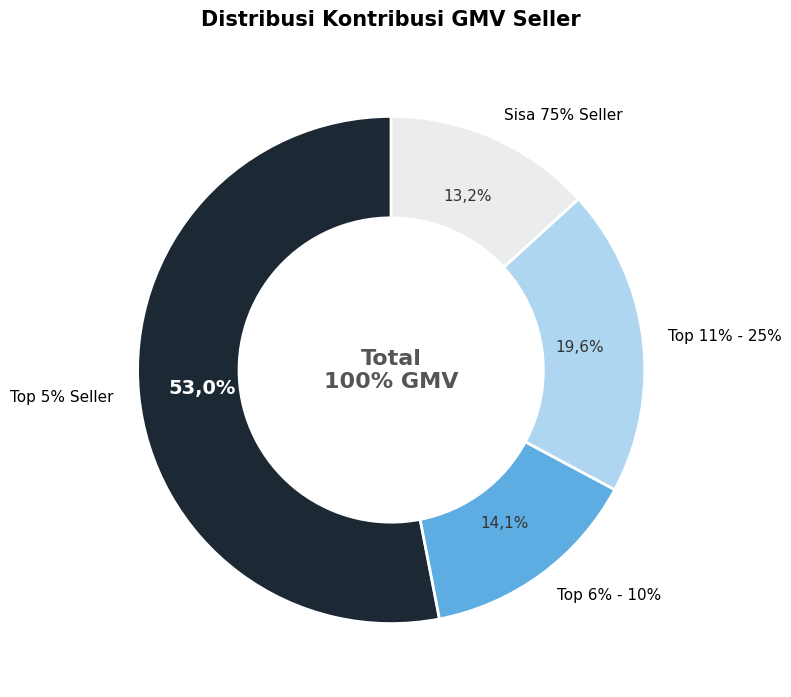

In [42]:
labels = [
    'Top 5% Seller',
    'Top 6% - 10%',
    'Top 11% - 25%',
    'Sisa 75% Seller'
]
sizes = [53.05, 14.13, 19.60, 13.22]
colors = ['#1C2833', '#5DADE2', '#AED6F1', '#EAECEE']
plt.figure(figsize=(8, 8))

# --- 3. MEMBUAT DONUT CHART ---
# wedgeprops={'width': 0.4} untuk melubangi tengahnya menjadi donat
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,          # Memulai dari sudut atas (jam 12)
    pctdistance=0.75,       # Posisi teks persentase
    textprops={'fontsize': 11},
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2}
)

# --- 4. KOSMETIK TEKS PERSENTASE ---
# Membuat angka persentase Top 5% menjadi warna putih dan tebal agar terbaca
for i, autotext in enumerate(autotexts):
    autotext.set_text(autotext.get_text().replace('.', ',')) # Format koma Indonesia
    if i == 0:
        autotext.set_color('white')
        autotext.set_weight('bold')
        autotext.set_fontsize(14)
    else:
        autotext.set_color('#333333')

# --- 5. TEKS DI TENGAH DONAT (PENTING UNTUK ORANG AWAM) ---
# Menambahkan kesimpulan di lubang tengah donat
plt.text(
    0, 0,
    "Total\n100% GMV",
    ha='center', va='center',
    fontsize=16, fontweight='bold', color='#555555'
)

plt.title('Distribusi Kontribusi GMV Seller', fontsize=15, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

💡 **Insight :**

Total seller : 2959
* Kontribusi GMV Top 25% Seller sebesar 86.78 %
* Kontribusi GMV Top 10% Seller sebesar 67.18 %
* Kontribusi GMV Top 5% Seller sebesar 53.05 %

Berdasarkan hal temuan tersebut, menunjukkan bahwa 75% seller hanya menyumbang 13% GMV atau **platform sangat bergantung pada sedikit seller**.

🚨**Warning**

Jika 5% seller ini pindah platform, dikenai penalti, kehabisan stok, atau turun performa → Dampak ke total GMV bisa besar.

Karena distribusinya sangat timpang, maka pertanyaannya bukan lagi:

**“Apa yang membuat top seller berbeda?”**

Tapi lebih tepat:

**“Apa yang menghambat 75% seller lainnya?”**

Karena jika kita bisa menaikkan kontribusi middle 50% saja sedikit, dampaknya ke GMV total bisa besar.

## Menemukan faktor kunci yang memengaruhi GMV dan pertumbuhan seller

In [ ]:
#kpi yang berhubungan dengan service dari seller
kpi = ['median_seller_processing_days','median_delivery_time_days','late_delivery_rate','avg_review_score','review_coverage']

In [ ]:

bot25_sellers[kpi].describe()

,median_seller_processing_days,median_delivery_time_days,late_delivery_rate,avg_review_score,review_coverage
count,740.000000,740.000000,740.000000,736.000000,740.000000
mean,3.218919,6.955405,0.069558,4.162367,0.993468
std,5.219801,8.617298,0.227483,1.166670,0.075429
min,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.500000,3.000000,0.000000,4.000000,1.000000
50%,2.000000,5.500000,0.000000,4.750000,1.000000
75%,4.000000,8.000000,0.000000,5.000000,1.000000
max,48.000000,186.000000,1.000000,5.000000,1.000000


In [ ]:
top25_sellers[kpi].describe()

,median_seller_processing_days,median_delivery_time_days,late_delivery_rate,avg_review_score,review_coverage
count,740.000000,740.000000,740.000000,739.000000,740.000000
mean,1.919595,6.888514,0.068777,4.096800,0.989926
std,2.273715,2.230934,0.074229,0.406331,0.041763
min,0.000000,0.000000,0.000000,1.400000,0.000000
25%,1.000000,6.000000,0.026147,3.909091,0.990804
50%,1.000000,7.000000,0.053667,4.153846,1.000000
75%,2.000000,8.000000,0.090909,4.350000,1.000000
max,21.000000,18.000000,1.000000,5.000000,1.000000


KPI	Top 25%
* Median processing	1 hari
* Median delivery	7 hari
* Late rate	5.36%
* Avg review score	4.15
* Review coverage	100%

KPI	Bottom 25%
* Median processing	2 hari
* Median delivery	5.5 hari
* Late rate	0%
* Avg review score	4.75
* Review coverage	100%

💡 **Insight Sementara**

* Service KPI tidak menjelaskan gap GMV
* Distribusi GMV sangat timpang

Karena dari service KPI tidak bergitu menjelaskan gap, kemungkinan besar GMV lebih dipengaruhi oleh kategori dan elastisitas permintaan daripada operasional.

Selanjutnya akan dicek kategori seller

In [ ]:
category_top25 = top25_sellers.groupby('product_category').agg({'total_gmv':'sum'}).sort_values(by='total_gmv', ascending=False)
category_top25.head()

,total_gmv
product_category,
watches_gifts,1253481.31
health_beauty,1201071.54
bed_bath_table,961110.60
sports_leisure,796974.05
computers_accessories,789837.96


In [ ]:
category_bot25 = bot25_sellers.groupby('product_category').agg({'total_gmv':'sum'}).sort_values(by='total_gmv', ascending=False)
category_bot25.head()

,total_gmv
product_category,
health_beauty,9174.35
housewares,6971.40
sports_leisure,5965.22
furniture_decor,5521.45
auto,4874.35


💡 Insight Penting

Terdapat dua kategori yang sama yaitu sports leisure dan health beauty. Artinya, kategori memang overlap dan bukan kategori yang membedakan Top vs Bottom, tapi scale dalam kategori tersebut.

In [ ]:
# kpi dari segi volume dam harga
kpi_2 = ['total_orders', 'total_items_sold', 'avg_item_price']

In [ ]:
top25_sellers[kpi_2].describe()

,total_orders,total_items_sold,avg_item_price
count,740.000000,740.000000,740.000000
mean,120.032432,120.032432,304.095040
std,215.232704,215.232704,573.216488
min,1.000000,1.000000,17.190524
25%,28.000000,28.000000,90.231214
50%,60.000000,60.000000,138.162835
75%,124.000000,124.000000,288.307517
max,1942.000000,1942.000000,6735.000000


In [ ]:
bot25_sellers[kpi_2].describe()

,total_orders,total_items_sold,avg_item_price
count,740.000000,740.000000,740.000000
mean,2.101351,2.101351,64.892671
std,1.677439,1.677439,47.623125
min,1.000000,1.000000,6.000000
25%,1.000000,1.000000,29.375000
50%,1.000000,1.000000,49.850000
75%,3.000000,3.000000,89.000000
max,11.000000,11.000000,214.080000


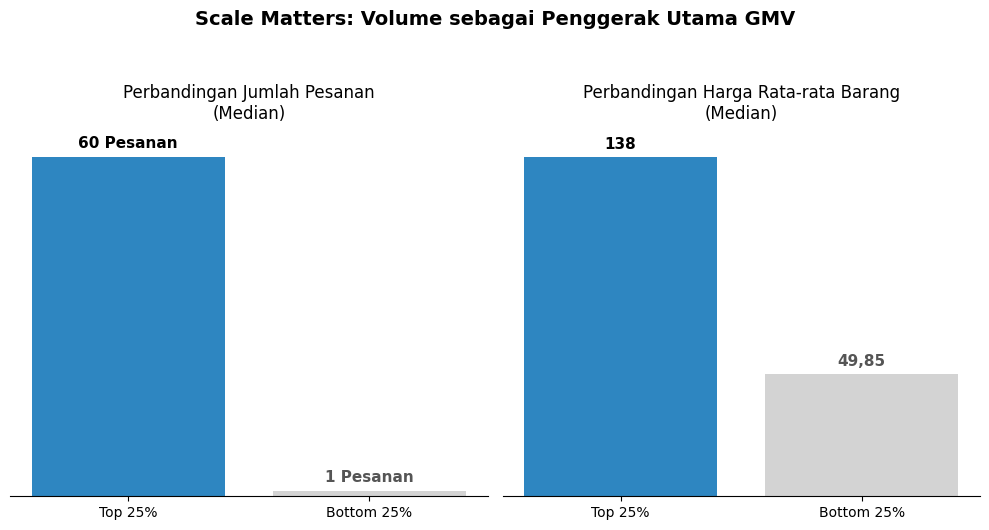

In [23]:
# --- 1. PERSIAPAN DATA ---
# Ubah label menjadi Bahasa Indonesia dan tambahkan enter (\n) agar tidak terlalu melebar
segments = ['Top 25%', 'Bottom 25%']
median_orders = [60, 1]
median_price = [138, 49.85]

# --- 2. SETUP VISUALISASI BERDAMPINGAN ---
# Membuat 1 baris, 2 kolom grafik agar ceritanya menyatu
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Warna: Fokuskan mata pada "Penjual Terbaik"
colors = ['#2E86C1', '#D3D3D3'] # Biru Tua & Abu-abu

# --- 3. GRAFIK KIRI: JUMLAH PESANAN ---
axes[0].bar(segments, median_orders, color=colors)
axes[0].set_title('Perbandingan Jumlah Pesanan\n(Median)', fontsize=12, pad=15)

# Label Angka untuk Grafik Kiri
for i, v in enumerate(median_orders):
    axes[0].text(
        i, v + 1,
        f'{v} Pesanan',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='black' if i==0 else '#555555'
    )

# --- 4. GRAFIK KANAN: HARGA RATA-RATA ---
axes[1].bar(segments, median_price, color=colors)
axes[1].set_title('Perbandingan Harga Rata-rata Barang\n(Median)', fontsize=12, pad=15)

# Label Angka untuk Grafik Kanan
for i, v in enumerate(median_price):
    # Format angka
    label_text = str(v).replace('.', ',')
    axes[1].text(
        i, v + 2,
        f'{label_text}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='black' if i==0 else '#555555'
    )

# --- 5. KOSMETIK & JUDUL UTAMA ---
# Membersihkan garis pinggir yang tidak perlu di kedua grafik
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([]) # Hilangkan angka di sumbu Y (karena sudah ada label di atas batang)

# Tambahkan "Kesimpulan" sebagai judul utama besar di paling atas
fig.suptitle(
    'Scale Matters: Volume sebagai Penggerak Utama GMV',
    fontsize=14, fontweight='bold', y=1.05
)

plt.tight_layout()
plt.show()

📊 Median Comparison (50%)

🔵 Top 25%
* Total orders = 60
* Total items sold = 60
* Avg item price ≈ 138

🔴 Bottom 25%
* Total orders = 1
* Total items sold = 1
* Avg item price ≈ 49.85

💡Insight

Perbedaan terbesar ada di Volume, bukan hanya harga.

Gap:

* Orders: 60 vs 1 → **60x lebih banyak**
* Items: 60 vs 1 → **60x lebih banyak**
* Price: 138 vs 49 → **~2.8x lebih mahal**

Secara matematis: GMV = Price × Volume

* Volume gap = 60x
* Price gap = 2.8x

👉 Volume adalah driver utama, Price hanya memperkuat.

## 3. Menentukan area perbaikan operasional yang paling berdampak

🧠 Insight

Bottom 25% bukan underperform karena:
* Lambat
* Rating jelek
* Terlambat kirim

Data menunjukkan service bukan pembeda utama. Mereka underperform karena, mereka hampir tidak punya transaksi.Itu diagnosis yang sangat penting.

## Mendukung pengambilan keputusan berbasis data untuk pengembangan seller UMKM

🎯 Strategi SMB yang Masuk Akal Berdasarkan Data
Untuk Bottom 25%:

Short-term :
* Campaign boost
* Free ads credit
* Push ke affiliate/live

Medium-term:
* Edukasi optimasi listing
* Edukasi thumbnail & title
* Edukasi bundling

Long-term:
* Kurasi seller yang benar-benar tidak viable